<img src="../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../images/Konstanz_Logo.svg" width="200" /> <img src="../images/KIT_Logo.png" width="200" />

# Exploring the Titanic Dataset with Pandas

In the previous notebook we learned what Series and DataFrames are and how to move
around inside them. Now we put those tools to work on a real question.

The *Titanic* sank on 15 April 1912 and around two thirds of the people aboard died.
But not at random. Our dataset holds 891 passengers, and for each one it records
who they were — their age, their sex, the class of their ticket, how much they paid,
who they travelled with — **and whether they survived**.

The goal of this notebook is to find out **what distinguished the people who
survived from those who did not**. Everything we do is ordinary pandas: selecting
columns, grouping, counting, plotting. The interest lies in what the numbers say.

---

## Contents

1. [The data](#data)
2. [What describe() does not tell us](#categorical)
3. [Who survived at all?](#baseline)
4. [Survival by sex](#sex)
5. [Survival by class](#class)
6. [Survival by age](#age)
7. [The missing ages, and a trick to recover some of them](#missing)

<a id="data"></a>
## 1. The data

Every row is one passenger, described by eleven **features**:

| Column | Meaning |
|---|---|
| **PassengerId** | A simple running number |
| **Pclass** | Ticket class: 1 = first, 2 = second, 3 = third |
| **Name** | Full name, including the title (Mr, Mrs, Miss, …) |
| **Sex** | `male` or `female` |
| **Age** | Age in years — *not known for everyone* |
| **SibSp** | Number of siblings and spouses aboard |
| **Parch** | Number of parents and children aboard |
| **Ticket** | Ticket number |
| **Fare** | Price paid for the ticket |
| **Cabin** | Cabin number — *known for very few passengers* |
| **Embarked** | Port of boarding: C = Cherbourg, Q = Queenstown, S = Southampton |

And one column that is the answer to our question:

| Column | Meaning |
|---|---|
| **Survived** | `1` if the passenger survived, `0` if not |

*Data source: [https://www.kaggle.com/datasets/yasserh/titanic-dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic.csv")
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


In [2]:
print("Passengers:", df.shape[0])
print("Columns:   ", df.shape[1])

Passengers: 891
Columns:    12


### 1.1 The statistical summary

`describe()` is the usual first look at a table: count, mean, spread, minimum,
maximum and the quartiles of every column.

In [3]:
df.describe().round(2)

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,891.00,891.00,714.00,891.00,891.00,891.00,891.00
mean,446.00,2.31,29.70,0.52,0.38,32.20,0.38
std,257.35,0.84,14.53,1.10,0.81,49.69,0.49
min,1.00,1.00,0.42,0.00,0.00,0.00,0.00
25%,223.50,2.00,20.12,0.00,0.00,7.91,0.00
50%,446.00,3.00,28.00,0.00,0.00,14.45,0.00
75%,668.50,3.00,38.00,1.00,0.00,31.00,1.00
max,891.00,3.00,80.00,8.00,6.00,512.33,1.00


A few things stand out already:

- **`Age` counts only 714**, not 891. Where the other columns report 891 values,
  this one reports fewer — the first sign that some ages are missing.
- **`Fare` runs from 0 to 512.33**, with a median of 14.45. A handful of very
  expensive tickets stretch the range far beyond where most passengers sit.
- **`Survived` has a mean of 0.38.** For a column of 0s and 1s the mean *is* the
  proportion — so 38% of these passengers survived.

<a id="categorical"></a>
## 2. What describe() does not tell us

Look closely at which columns appeared in that table.

In [4]:
list(df.describe().columns)

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']

Five columns are missing: `Name`, `Sex`, `Ticket`, `Cabin` and `Embarked`. By
default `describe()` only summarises **numeric** columns, and for good reason —
there is no such thing as the mean of `male` and `female`.

Columns like these are called **categorical**: they hold labels, not quantities.
They need a different kind of summary, which `describe()` can also produce.

In [5]:
df.describe(exclude="number")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


Different statistics entirely: how many values there are, how many are **unique**,
which is the **most frequent** and how often it occurs.

That immediately separates two kinds of categorical column:

- `Sex` has 2 unique values and `Embarked` has 3 — real categories, worth grouping by
- `Name` has 891 unique values in 891 rows, and `Ticket` has 681 — these are
  identifiers, and grouping by them would be pointless

For the genuine categories, `value_counts()` shows the whole picture rather than
just the most common entry.

In [6]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [7]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

One more warning sign is hidden in the table above: `Cabin` has a count of 204
while `Embarked` has 889 and everything else has 891. Missing values again, and this
time far more of them.

`isna()` marks every missing value as `True`, so summing it counts them per column.

In [8]:
df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Survived         0
dtype: int64

Three columns have gaps, and they are of very different size:

- **`Cabin`, 687 missing (77%)** — so little is left that the column is barely usable
- **`Age`, 177 missing (20%)** — a serious hole in an otherwise useful column, and
  we come back to it in [section 7](#missing)
- **`Embarked`, 2 missing** — small enough to ignore

Everything else, including `Sex`, `Pclass` and `Survived`, is complete.

<a id="baseline"></a>
## 3. Who survived at all?

Before comparing groups, we need the number that every group will be compared
against: the overall survival rate.

In [9]:
print(f"Survived: {df['Survived'].sum()}")
print(f"Died:     {(df['Survived'] == 0).sum()}")
print(f"Overall survival rate: {df['Survived'].mean():.1%}")

Survived: 342
Died:     549
Overall survival rate: 38.4%


**38.4%.** That is our reference line. Any group that does much better or much
worse than this tells us something about who had a chance that night.

<a id="sex"></a>
## 4. Survival by sex

`groupby` splits the table into groups and applies a calculation to each one.
Because `Survived` is 0 or 1, taking the **mean** of each group gives that group's
survival rate directly.

In [10]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()
survival_by_sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

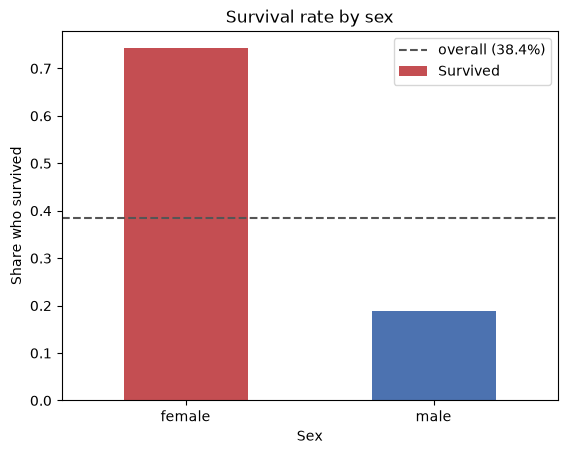

In [11]:
survival_by_sex.plot(kind="bar", rot=0, color=["#c44e52", "#4c72b0"])
plt.axhline(df["Survived"].mean(), color="#555555", linestyle="--",
            label="overall (38.4%)")
plt.title("Survival rate by sex")
plt.ylabel("Share who survived")
plt.legend()
plt.show()

This is the single strongest pattern in the dataset. **74% of the women survived
and only 19% of the men** — a woman aboard was almost four times as likely to live.

"Women and children first" was not just a phrase; it is visible directly in the
data.

<a id="class"></a>
## 5. Survival by class

The other obvious candidate is the ticket class.

In [12]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

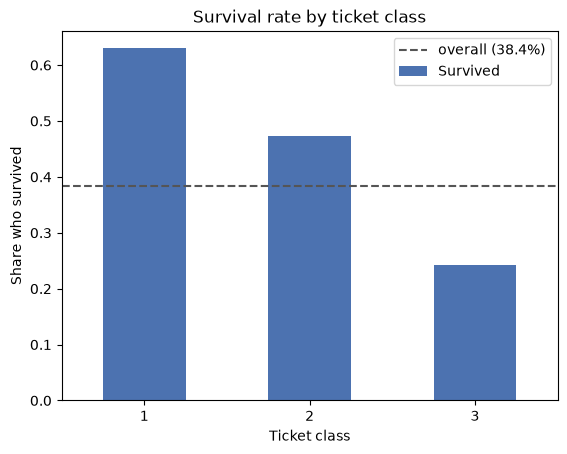

In [13]:
survival_by_class.plot(kind="bar", rot=0, color="#4c72b0")
plt.axhline(df["Survived"].mean(), color="#555555", linestyle="--",
            label="overall (38.4%)")
plt.title("Survival rate by ticket class")
plt.xlabel("Ticket class")
plt.ylabel("Share who survived")
plt.legend()
plt.show()

Again a clear gradient: **63% in first class, 47% in second, 24% in third.** The
further down in the ship — and in society — a passenger was, the smaller their
chance.

Both patterns are strong, which raises an obvious follow-up: which of the two
mattered more? `groupby` accepts several columns at once, and `unstack` lays the
result out as a table.

In [14]:
df.groupby(["Sex", "Pclass"])["Survived"].mean().unstack().round(3)

Pclass,1,2,3
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


Read that table carefully. A woman in **third** class survived at 50%, while a man
in **first** class survived at 37%.

Class mattered — but sex mattered more.

<a id="age"></a>
## 6. Survival by age

Age is not a category but a continuous number, so a bar chart per value would be
useless. A **histogram** is the right tool: it sorts the passengers into age
brackets and counts how many fall into each.

Drawing the survivors and the dead side by side lets us compare the two.

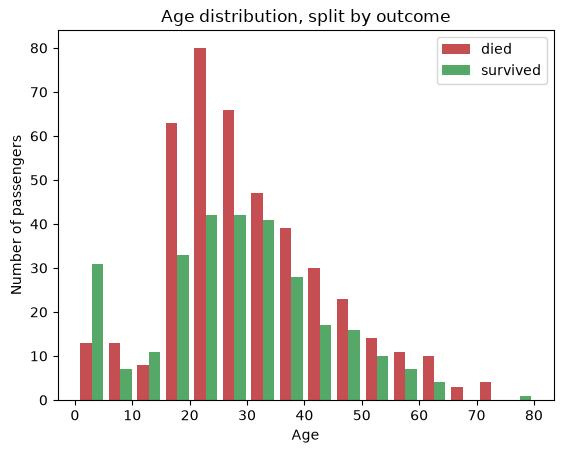

In [15]:
age_survived = df[df["Survived"] == 1]["Age"].dropna()
age_died = df[df["Survived"] == 0]["Age"].dropna()

plt.hist([age_died, age_survived], bins=16,
         label=["died", "survived"], color=["#c44e52", "#55a868"])
plt.title("Age distribution, split by outcome")
plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.legend()
plt.show()

At the very left of the chart — the youngest bracket — the green bar is taller than
the red one. It is the only place in the whole histogram where that happens.

In [16]:
children = df[df["Age"] <= 12]

print(f"Children (12 or younger): {len(children)}")
print(f"Their survival rate:      {children['Survived'].mean():.1%}")
print(f"Overall survival rate:    {df['Survived'].mean():.1%}")

Children (12 or younger): 69
Their survival rate:      58.0%
Overall survival rate:    38.4%


**58% against 38%.** The other half of "women and children first" is in the data too.

But notice what the histogram is quietly hiding. We had to write `.dropna()` twice
to draw it at all.

In [17]:
print(f"Passengers in the dataset: {len(df)}")
print(f"Passengers in the chart:   {df['Age'].notna().sum()}")
print(f"Left out:                  {df['Age'].isna().sum()}")

Passengers in the dataset: 891
Passengers in the chart:   714
Left out:                  177


**177 passengers are missing from that chart** and nothing about it says so. The
axes look complete, the bars look reasonable, and a fifth of the data is simply not
there.

<a id="missing"></a>
## 7. The missing ages, and a trick to recover some of them

We cannot invent the missing ages. But we do not need the exact number — for the
question "was this passenger a child?" something coarser is enough.

And there is a clue sitting in a column we have ignored so far: **`Name`**.

In [18]:
df["Name"].head(8)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
Name: Name, dtype: str

Look at how the names are written. Every one contains a **title**: *Mr*, *Mrs*,
*Miss* — and, for some, **Master**.

In 1912 English, *Master* was the formal address for a **boy** who was too young to
be called *Mr*. It was not a name or a rank; it was an age marker, written down for
us in a column that has no missing values at all.

Finding it needs nothing clever. `str.contains` checks each name for a piece of text
and returns a boolean mask, exactly like the comparisons in [section 4](#sex) — only
on text instead of numbers.

In [19]:
is_master = df["Name"].str.contains("Master")

print(f"Passengers with 'Master' in their name: {is_master.sum()}")

Passengers with 'Master' in their name: 40


In [20]:
df[is_master][["Name", "Age", "Survived"]].head()

,Name,Age,Survived
7,"Palsson, Master. Gosta Leonard",2.0,0
16,"Rice, Master. Eugene",2.0,0
50,"Panula, Master. Juha Niilo",7.0,0
59,"Goodwin, Master. William Frederick",11.0,0
63,"Skoog, Master. Harald",4.0,0


Now the key question: does *Master* really mean "boy"? We can check it against the
ages we *do* know.

In [21]:
masters_with_age = df[is_master & df["Age"].notna()]

print(f"Passengers titled 'Master' with a known age: {len(masters_with_age)}")
print(f"Youngest: {masters_with_age['Age'].min()} years")
print(f"Oldest:   {masters_with_age['Age'].max()} years")

Passengers titled 'Master' with a known age: 36
Youngest: 0.42 years
Oldest:   12.0 years


**The oldest is 12.** Not one exception. Whenever the age is known, *Master* means
a child — so where the age is unknown, the title is trustworthy evidence.

So let us take the passengers whose age is missing and apply the same check to them.

In [22]:
missing_age = df[df["Age"].isna()]

hidden_boys = missing_age[missing_age["Name"].str.contains("Master")]
hidden_boys[["Name", "Pclass", "Age", "Survived"]]

,Name,Pclass,Age,Survived
65,"Moubarek, Master. Gerios",3,NaN,1
159,"Sage, Master. Thomas Henry",3,NaN,0
176,"Lefebre, Master. Henry Forbes",3,NaN,0
709,"Moubarek, Master. Halim Gonios (""William George"")",3,NaN,1


Four boys, invisible in the histogram in [section 6](#age) because their `Age` cell
is empty — but identifiable as children all the same.

In [23]:
print(f"Children found through Age:     {len(children)}")
print(f"Children found through 'Master': {len(hidden_boys)}")
print(f"Total:                          {len(children) + len(hidden_boys)}")
print()
print(f"Of those {len(hidden_boys)} boys, {hidden_boys['Survived'].sum()} survived and "
      f"{(hidden_boys['Survived'] == 0).sum()} died")

Children found through Age:     69
Children found through 'Master': 4
Total:                          73

Of those 4 boys, 2 survived and 2 died


Four extra children out of 69 is a modest gain. What matters is the idea: **a column we never thought of as data
turned out to carry the very information another column was missing.**